# CIFAR-10: shallow CNN in PyTorch and JAX — results

This notebook presents the results of the project. It reads everything from the
MLflow runs created by the training scripts, so it trains nothing itself.

1. **The dataset** — what CIFAR-10 looks like and how it is split
2. **The model** — the shallow CNN and how its size depends on depth and width
3. **Stage 1: hyperparameter sweep** — 9 PyTorch runs over depth × width, managed by Hydra
4. **Stage 2: PyTorch vs JAX** — the winning architecture in both frameworks, 3 seeds each
5. **A look at the predictions** — what the trained models get right and wrong
6. **Takeaways**

The saved outputs come from the author's GPU run. To regenerate them after
training (see the README), run from the repository root:

```
jupyter nbconvert --to notebook --execute --inplace notebooks/results.ipynb
```

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # let JAX and PyTorch share the GPU
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf

import results
from data import CLASS_NAMES, load_cifar10, load_raw_cifar10

pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})
# The same settings the training script used (Hydra merges these files at run time).
cfg = OmegaConf.load(REPO_ROOT / "conf" / "config.yaml")
model_cfg = OmegaConf.load(REPO_ROOT / "conf" / "model" / "shallow_cnn.yaml")

## 1. The dataset

CIFAR-10 has 60,000 colour images of 32 × 32 pixels in 10 classes. torchvision
downloads it; both frameworks then share the same NumPy arrays (see `src/data.py`).
The official 50,000 training images are split into 45,000 for training and
5,000 for validation; the 10,000 official test images are only used at the very end.

In [2]:
x_train_raw, y_train_raw, _, _ = load_raw_cifar10(REPO_ROOT / cfg.data.dir)
data = load_cifar10(REPO_ROOT / cfg.data.dir, cfg.data.val_size, cfg.data.split_seed)

# How many images of each class ended up in each split?
counts = pd.DataFrame({
    split: pd.Series(getattr(data, split).y).value_counts().sort_index()
    for split in ["train", "val", "test"]
})
counts.index = CLASS_NAMES
counts.loc["total"] = counts.sum()
counts

,train,val,test
airplane,4482,518,1000
automobile,4509,491,1000
bird,4474,526,1000
cat,4513,487,1000
deer,4477,523,1000
dog,4509,491,1000
frog,4522,478,1000
horse,4513,487,1000
ship,4481,519,1000
truck,4520,480,1000


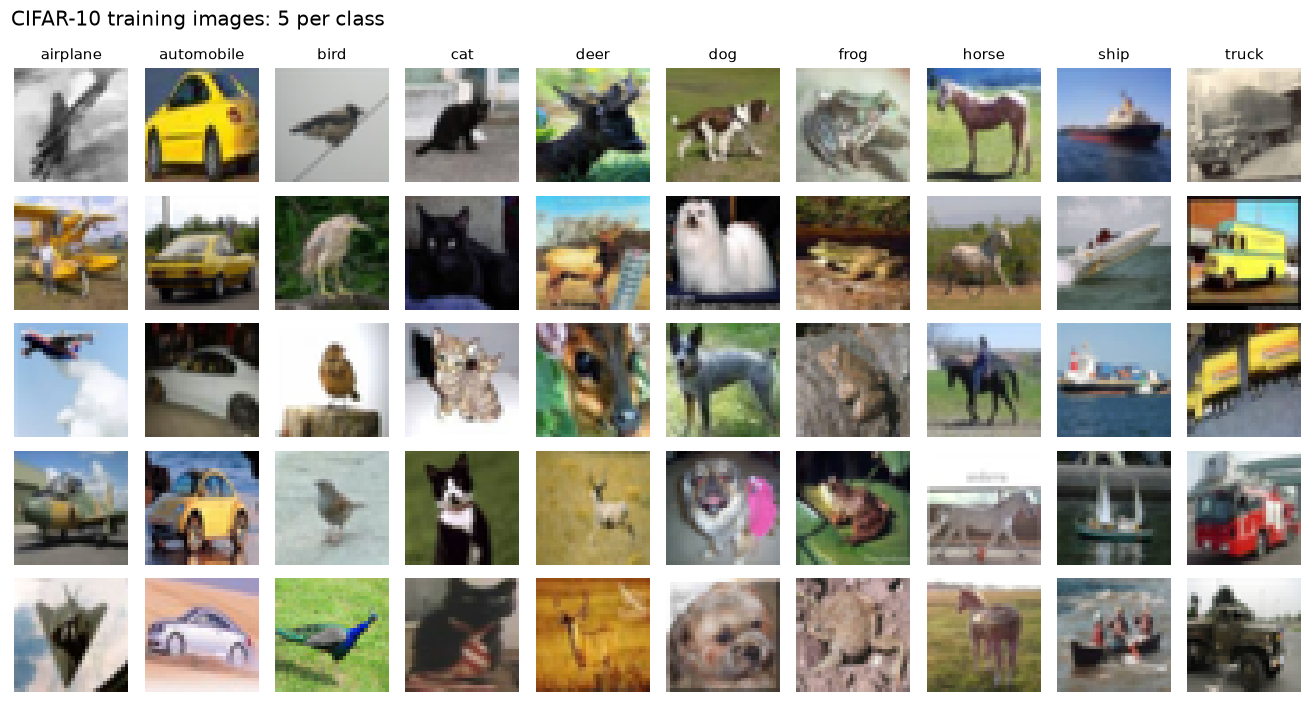

In [3]:
# Five random examples of every class (raw pixels, before normalisation).
rng = np.random.default_rng(0)
fig, axes = plt.subplots(5, 10, figsize=(12, 6.5))
for col, class_name in enumerate(CLASS_NAMES):
    examples = rng.choice(np.flatnonzero(y_train_raw == col), size=5, replace=False)
    for row, index in enumerate(examples):
        axes[row, col].imshow(x_train_raw[index])
        axes[row, col].axis("off")
    axes[0, col].set_title(class_name, fontsize=10)
fig.suptitle("CIFAR-10 training images: 5 per class", x=0.01, ha="left", fontsize=13)
fig.tight_layout()

## 2. The model

A deliberately shallow, VGG-style network, written the same way in
`src/torch_model.py` (PyTorch) and `src/jax_model.py` (Flax NNX):

```
input 32×32×3
→ [Conv 3×3 → ReLU → MaxPool 2×2] × num_blocks      (channels double each block)
→ Flatten → Dense 128 → ReLU → Dense 10
```

No BatchNorm or Dropout, so the two implementations stay simple and identical.
The table below counts the trainable parameters for each sweep configuration.
Note that **fewer blocks means more parameters**: with only one pooling layer the
feature map is still 16 × 16 when it is flattened, so the first dense layer is huge.

In [4]:
from torch_model import ShallowCNN, count_params

param_counts = pd.DataFrame(
    [{"num_blocks": b, "base_channels": c,
      "num_params": count_params(ShallowCNN(b, c, model_cfg.hidden_units, model_cfg.num_classes))}
     for b in (1, 2, 3) for c in (16, 32, 64)]
).pivot(index="num_blocks", columns="base_channels", values="num_params")
param_counts.style.format("{:,}").set_caption("Trainable parameters: conv blocks (rows) × base channels (columns)")

base_channels,16,32,64
num_blocks,,,
1,"526,154","1,050,890","2,100,362"
2,"268,650","545,098","1,125,642"
3,"156,074","356,810","896,522"


## 3. Stage 1: hyperparameter sweep (PyTorch)

Hydra ran every combination of two hyperparameters, keeping everything else fixed
(Adam, learning rate 0.001, batch size 128, 15 epochs, seed 42):

```
python src/train.py -m +experiment=sweep
```

| Hyperparameter | Values |
|---|---|
| `model.num_blocks` (depth) | 1, 2, 3 |
| `model.base_channels` (width) | 16, 32, 64 |

Each run was logged to MLflow. `mlflow.search_runs` returns the runs as a pandas
DataFrame; `src/results.py` tidies it. Runs are ranked by **final validation accuracy**.

In [5]:
sweep = results.load_runs(results.SWEEP_EXPERIMENT)
results.sweep_table(sweep).style.format({
    "num_params": "{:,}", "final_val_acc": "{:.2%}", "best_val_acc": "{:.2%}", "mean_epoch_time_s": "{:.1f}s",
})

,num_blocks,base_channels,num_params,final_val_acc,best_val_acc,mean_epoch_time_s
rank,,,,,,
0,3,64,"896,522",76.38%,77.24%,2.4s
1,3,16,"156,074",73.38%,73.38%,1.8s
2,3,32,"356,810",73.14%,75.08%,2.0s
3,2,64,"1,125,642",71.26%,72.94%,1.9s
4,2,32,"545,098",71.00%,72.92%,1.6s
5,2,16,"268,650",68.30%,69.34%,1.6s
6,1,32,"1,050,890",65.16%,67.04%,1.4s
7,1,64,"2,100,362",65.10%,67.08%,1.5s
8,1,16,"526,154",63.24%,66.14%,1.3s


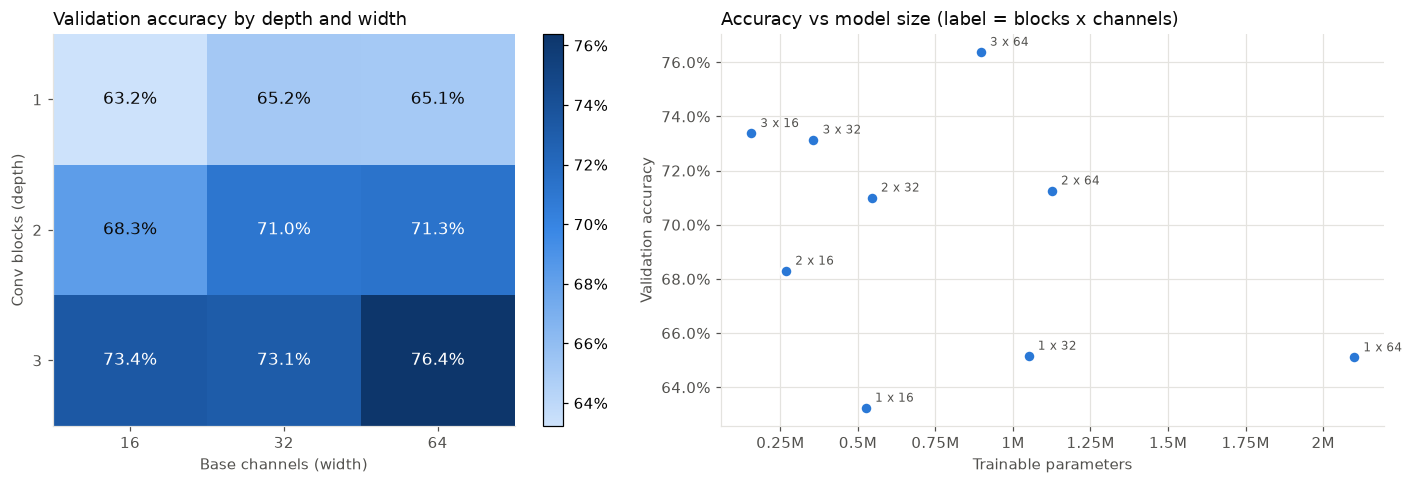

In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.15]})
results.plot_sweep_heatmap(results.sweep_grid(sweep), left)
results.plot_accuracy_vs_params(sweep, right)
fig.tight_layout()

In [7]:
winner = results.best_config(sweep)
print(f"Winner: {winner.num_blocks} conv blocks with {winner.base_channels} base channels "
      f"({winner.num_params:,} parameters), final validation accuracy {winner.final_val_acc:.2%}.")

Winner: 3 conv blocks with 64 base channels (896,522 parameters), final validation accuracy 76.38%.


## 4. Stage 2: PyTorch vs JAX

The winning architecture was trained again in **both frameworks, with 3 seeds each**,
and evaluated on the test set:

```
python src/train.py -m +experiment=compare model.num_blocks=<winner> model.base_channels=<winner>
```

Both frameworks read identical batches in identical order (same NumPy pipeline,
same seed). Only the weight initialisation differs, because PyTorch and Flax use
different default initialisers. Several seeds show whether any accuracy gap is real.

In [8]:
compare = results.load_runs(results.COMPARE_EXPERIMENT)
(compare.sort_values(["framework", "seed"])
 [["framework", "seed", "device", "num_params", "final_val_acc", "test_acc",
   "first_epoch_time_s", "mean_epoch_time_s", "total_train_time_s"]]
 .style.format({"num_params": "{:,}", "final_val_acc": "{:.2%}", "test_acc": "{:.2%}",
                "first_epoch_time_s": "{:.2f}s", "mean_epoch_time_s": "{:.2f}s", "total_train_time_s": "{:.1f}s"})
 .hide(axis="index"))

framework,seed,device,num_params,final_val_acc,test_acc,first_epoch_time_s,mean_epoch_time_s,total_train_time_s
jax,0,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",74.20%,75.00%,8.63s,2.33s,41.2s
jax,1,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",75.28%,74.89%,3.91s,2.25s,35.4s
jax,2,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",73.94%,73.68%,3.98s,2.25s,35.5s
torch,0,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",76.02%,75.87%,5.00s,2.58s,41.2s
torch,1,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",76.38%,75.98%,2.73s,2.65s,39.9s
torch,2,NVIDIA GeForce RTX 4070 Laptop GPU,"896,522",75.64%,75.34%,2.55s,2.62s,39.3s


The pandas summary below averages over the seeds. `speed_vs_torch` compares the
time per epoch *after the first*: JAX compiles the training step with XLA during
epoch 1, so including it would hide the steady-state speed.

In [9]:
summary = results.framework_summary(compare)
summary.style.format({
    "num_params": "{:,}", "test_acc_mean": "{:.2%}", "test_acc_std": "{:.2%}",
    "val_acc_mean": "{:.2%}", "val_acc_std": "{:.2%}", "first_epoch_s": "{:.2f}s",
    "later_epoch_s": "{:.2f}s", "total_train_s": "{:.1f}s", "speed_vs_torch": "{:.2f}x",
})

,runs,num_params,test_acc_mean,test_acc_std,val_acc_mean,val_acc_std,first_epoch_s,later_epoch_s,total_train_s,speed_vs_torch
framework,,,,,,,,,,
JAX,3,"896,522",74.52%,0.73%,74.47%,0.71%,5.50s,2.28s,37.4s,1.15x
PyTorch,3,"896,522",75.73%,0.34%,76.01%,0.37%,3.43s,2.62s,40.1s,1.00x


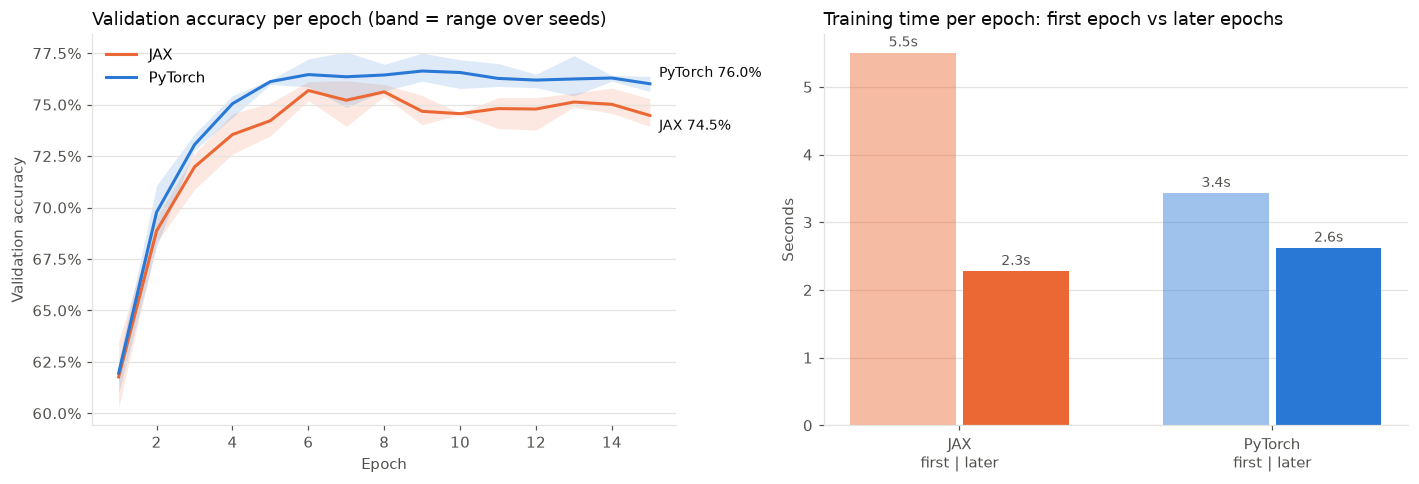

In [10]:
history = results.metric_history(compare, "val_acc")
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
results.plot_val_curves(history, left)
results.plot_epoch_times(summary, right)
fig.tight_layout()

## 5. A look at the predictions

We reload the best run of each framework from its MLflow artifacts and predict
the whole test set.

In [11]:
# The run with the highest test accuracy in each framework.
best_runs = compare.loc[compare.groupby("framework")["test_acc"].idxmax()]
predictions = {
    run.framework: results.load_trained_model(run).predict(data.test, batch_size=256)
    for _, run in best_runs.iterrows()
}
torch_pred, jax_pred, truth = predictions["torch"], predictions["jax"], data.test.y

agreement = (torch_pred == jax_pred).mean()
print(f"PyTorch test accuracy: {(torch_pred == truth).mean():.2%}")
print(f"JAX test accuracy:     {(jax_pred == truth).mean():.2%}")
print(f"The two models predict the same class for {agreement:.1%} of the test images.")

PyTorch test accuracy: 75.98%
JAX test accuracy:     75.00%
The two models predict the same class for 74.8% of the test images.


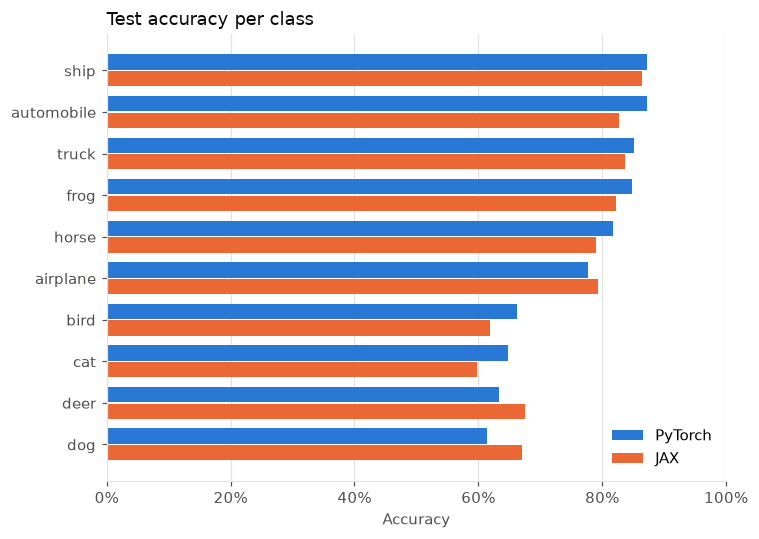

In [12]:
# Accuracy per class: which classes are hard for a shallow CNN?
per_class = pd.DataFrame({
    results.FRAMEWORK_LABELS[f]: [(predictions[f][truth == c] == c).mean() for c in range(10)]
    for f in ["torch", "jax"]
}, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 5))
results.plot_per_class_accuracy(per_class, ax)
fig.tight_layout()

In [13]:
# The most common mistakes of the PyTorch model, from a pandas crosstab of (true, predicted) pairs.
confusions = pd.crosstab(pd.Series(truth, name="true"), pd.Series(torch_pred, name="predicted"))
confusions.index, confusions.columns = CLASS_NAMES, CLASS_NAMES
mistakes = (confusions.stack().rename("count").reset_index()
            .rename(columns={"level_0": "true class", "level_1": "predicted as"}))
mistakes = mistakes[mistakes["true class"] != mistakes["predicted as"]]
mistakes.nlargest(8, "count").reset_index(drop=True)

,true class,predicted as,count
0,dog,cat,205
1,cat,dog,119
2,deer,cat,84
3,deer,bird,82
4,frog,cat,76
5,bird,cat,69
6,deer,frog,69
7,automobile,truck,66


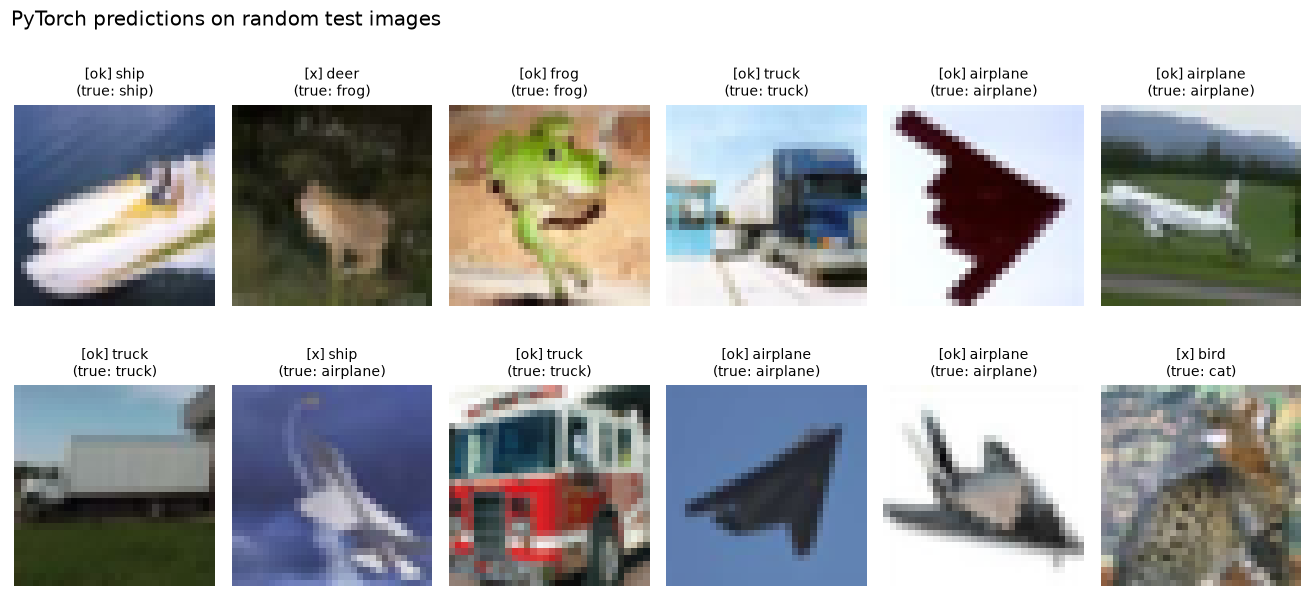

In [14]:
# Twelve random test images with the PyTorch prediction ("ok" = correct, "x" = wrong).
_, _, x_test_raw, _ = load_raw_cifar10(REPO_ROOT / cfg.data.dir)
sample = np.random.default_rng(1).choice(len(truth), size=12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(12, 6))
for ax, index in zip(axes.flat, sample):
    ax.imshow(x_test_raw[index])
    ax.axis("off")
    mark = "ok" if torch_pred[index] == truth[index] else "x"
    ax.set_title(f"[{mark}] {CLASS_NAMES[torch_pred[index]]}\n(true: {CLASS_NAMES[truth[index]]})", fontsize=9)
fig.suptitle("PyTorch predictions on random test images", x=0.01, ha="left", fontsize=13)
fig.tight_layout()

## 6. Takeaways

Computed from the results above:

In [15]:
grid = results.sweep_grid(sweep)
worst = sweep.loc[sweep["final_val_acc"].idxmin()]
smallest = sweep.loc[sweep["num_params"].idxmin()]
s = summary
print(f"- Sweep: validation accuracy ranged from {worst.final_val_acc:.1%} "
      f"({worst.num_blocks} block(s) x {worst.base_channels}) to {winner.final_val_acc:.1%} "
      f"({winner.num_blocks} x {winner.base_channels}).")
print(f"- Averaged over widths, accuracy by depth: "
      + ", ".join(f"{b} block(s) {v:.1%}" for b, v in grid.mean(axis=1).items()) + ".")
largest = sweep.loc[sweep["num_params"].idxmax()]
verdict = ("more parameters did not buy accuracy" if smallest.final_val_acc >= largest.final_val_acc
           else "the extra parameters did help")
print(f"- Smallest model ({smallest.num_blocks} x {smallest.base_channels}, {smallest.num_params:,} params): "
      f"{smallest.final_val_acc:.1%}; largest ({largest.num_blocks} x {largest.base_channels}, "
      f"{largest.num_params:,} params): {largest.final_val_acc:.1%}, so {verdict}.")
print(f"- Test accuracy: PyTorch {s.loc['PyTorch', 'test_acc_mean']:.2%} ± {s.loc['PyTorch', 'test_acc_std']:.2%}, "
      f"JAX {s.loc['JAX', 'test_acc_mean']:.2%} ± {s.loc['JAX', 'test_acc_std']:.2%} (mean ± std over seeds).")
print(f"- Speed after the first epoch: JAX ran at {s.loc['JAX', 'speed_vs_torch']:.2f}x the PyTorch speed (above 1 = faster); "
      f"its first epoch took {s.loc['JAX', 'first_epoch_s']:.1f}s vs {s.loc['JAX', 'later_epoch_s']:.1f}s later (XLA compilation).")
print(f"- Hardest class: {per_class['PyTorch'].idxmin()} ({per_class['PyTorch'].min():.0%}); "
      f"easiest: {per_class['PyTorch'].idxmax()} ({per_class['PyTorch'].max():.0%}).")

- Sweep: validation accuracy ranged from 63.2% (1 block(s) x 16) to 76.4% (3 x 64).
- Averaged over widths, accuracy by depth: 1 block(s) 64.5%, 2 block(s) 70.2%, 3 block(s) 74.3%.
- Smallest model (3 x 16, 156,074 params): 73.4%; largest (1 x 64, 2,100,362 params): 65.1%, so more parameters did not buy accuracy.
- Test accuracy: PyTorch 75.73% ± 0.34%, JAX 74.52% ± 0.73% (mean ± std over seeds).
- Speed after the first epoch: JAX ran at 1.15x the PyTorch speed (above 1 = faster); its first epoch took 5.5s vs 2.3s later (XLA compilation).
- Hardest class: dog (61%); easiest: automobile (87%).
